In [30]:
import torch
import torch.nn as nn

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
)

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cpu'


In [32]:
X_scaler = joblib.load("../data/weights/X_scaler.joblib")
y_scaler = joblib.load("../data/weights/y_scaler.joblib")
forecasts_len = 6
lmbda = 0

In [33]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        return x_window, y_window

In [34]:
def visualize_model(model, loader, y_scaler, lmbda):
  dst_labels = []
  ae_labels = []
  dst_preds = []
  ae_preds = []

  with torch.no_grad():
      model.eval()
      for x, y in loader:
          x, y = x.to(device), y.to(device)
          dst_pred, ae_pred, _ = model(x)
          preds = np.stack([dst_pred.cpu().numpy().flatten(), ae_pred.cpu().numpy().flatten()], axis=1)
          labels = np.stack([y[:, :, 0].cpu().numpy().flatten(), y[:, :, 1].cpu().numpy().flatten()], axis=1)
          preds = y_scaler.inverse_transform(preds)
          preds[:, 1] = inv_boxcox(preds[:, 1], lmbda)
          labels = y_scaler.inverse_transform(labels)
          labels[:, 1] = inv_boxcox(labels[:, 1], lmbda)
          dst_preds.extend(preds[:, 0])
          ae_preds.extend(preds[:, 1])
          dst_labels.extend(labels[:, 0])
          ae_labels.extend(labels[:, 1])

  _, axes = plt.subplots(2, 1, figsize=(14, 5))
  axes[0].set_title("Dst")
  axes[0].plot(dst_labels, label="original")
  axes[0].plot(np.array(dst_preds), label="predict")
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  axes[1].set_title("AE")
  axes[1].plot(ae_labels, label="original")
  axes[1].plot(ae_preds, label="predict")
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

In [35]:
def inference_with_ci(model, loader, y_scaler, lmbda, device='cpu', alpha=0.95, n_points=8000):
    """Визуализация с доверительными интервалами - красивая версия для больших данных"""
    dst_labels = []
    ae_labels = []
    dst_preds = []
    ae_preds = []
    dst_errors = []
    ae_errors = []

    with torch.no_grad():
        model.eval()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            dst_pred, ae_pred, _ = model(x)
            
            preds = np.stack([dst_pred.cpu().numpy().flatten(), ae_pred.cpu().numpy().flatten()], axis=1)
            labels = np.stack([y[:, :, 0].cpu().numpy().flatten(), y[:, :, 1].cpu().numpy().flatten()], axis=1)
            
            preds = y_scaler.inverse_transform(preds)
            preds[:, 1] = inv_boxcox(preds[:, 1], lmbda)
            labels = y_scaler.inverse_transform(labels)
            labels[:, 1] = inv_boxcox(labels[:, 1], lmbda)
            
            dst_preds.extend(preds[:, 0])
            ae_preds.extend(preds[:, 1])
            dst_labels.extend(labels[:, 0])
            ae_labels.extend(labels[:, 1])
            dst_errors.extend(labels[:, 0] - preds[:, 0])
            ae_errors.extend(labels[:, 1] - preds[:, 1])
    
    dst_preds = np.array(dst_preds)
    ae_preds = np.array(ae_preds)
    dst_labels = np.array(dst_labels)
    ae_labels = np.array(ae_labels)
    dst_errors = np.array(dst_errors)
    ae_errors = np.array(ae_errors)
    
    dst_std = np.std(dst_errors)
    ae_std = np.std(ae_errors)
    dst_mean = np.mean(dst_errors)
    ae_mean = np.mean(ae_errors)
    
    z = stats.norm.ppf((1 + alpha) / 2)
    
    dst_ci_lower = dst_preds + (dst_mean - z * dst_std)
    dst_ci_upper = dst_preds + (dst_mean + z * dst_std)
    ae_ci_lower = ae_preds + (ae_mean - z * ae_std)
    ae_ci_upper = ae_preds + (ae_mean + z * ae_std)
    
    # Ограничиваем количество точек для показа (если данных больше n_points)
    n_total = len(dst_labels)
    if n_total > n_points:
        indices = np.linspace(0, n_total - 1, n_points, dtype=int)
        dst_labels = dst_labels[indices]
        dst_preds = dst_preds[indices]
        dst_ci_lower = dst_ci_lower[indices]
        dst_ci_upper = dst_ci_upper[indices]
        ae_labels = ae_labels[indices]
        ae_preds = ae_preds[indices]
        ae_ci_lower = ae_ci_lower[indices]
        ae_ci_upper = ae_ci_upper[indices]
    
    # Создаем красивый график
    # fig = plt.figure(figsize=(18, 8))
    
    # # DST
    # ax1 = plt.subplot(1, 2, 1)
    # ax1.plot(dst_labels, color='#1f77b4', linewidth=1.2, alpha=0.8, label='Истинные значения')
    # ax1.plot(dst_preds, color='#ff7f0e', linewidth=1.2, alpha=0.8, label='Предсказания')
    # ax1.fill_between(range(len(dst_preds)), dst_ci_lower, dst_ci_upper, 
    #                   color='#ff7f0e', alpha=0.25, label=f'Доверительный интервал ({int(alpha*100)}%)')
    # ax1.set_title('Индекс Dst', fontsize=14, fontweight='bold')
    # ax1.set_xlabel('Временные шаги', fontsize=12)
    # ax1.set_ylabel('Dst, nT', fontsize=12)
    # ax1.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    # ax1.grid(True, alpha=0.3, linestyle='--')
    # ax1.set_facecolor('#f9f9f9')
    
    # # Статистика для Dst
    # dst_rmse = np.sqrt(np.mean(dst_errors**2))
    # dst_mae = np.mean(np.abs(dst_errors))
    # ax1.text(0.02, 0.95, f'RMSE = {dst_rmse:.2f} nT\nMAE = {dst_mae:.2f} nT\nStd = {dst_std:.2f} nT', 
    #          transform=ax1.transAxes, fontsize=10, verticalalignment='top',
    #          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # # AE
    # ax2 = plt.subplot(1, 2, 2)
    # ax2.plot(ae_labels, color='#1f77b4', linewidth=1.2, alpha=0.8, label='Истинные значения')
    # ax2.plot(ae_preds, color='#ff7f0e', linewidth=1.2, alpha=0.8, label='Предсказания')
    # ax2.fill_between(range(len(ae_preds)), ae_ci_lower, ae_ci_upper, 
    #                   color='#ff7f0e', alpha=0.25, label=f'Доверительный интервал ({int(alpha*100)}%)')
    # ax2.set_title('Индекс AE', fontsize=14, fontweight='bold')
    # ax2.set_xlabel('Временные шаги', fontsize=12)
    # ax2.set_ylabel('AE, nT', fontsize=12)
    # ax2.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    # ax2.grid(True, alpha=0.3, linestyle='--')
    # ax2.set_facecolor('#f9f9f9')
    
    # # Статистика для AE
    # ae_rmse = np.sqrt(np.mean(ae_errors**2))
    # ae_mae = np.mean(np.abs(ae_errors))
    # ax2.text(0.02, 0.95, f'RMSE = {ae_rmse:.2f} nT\nMAE = {ae_mae:.2f} nT\nStd = {ae_std:.2f} nT', 
    #          transform=ax2.transAxes, fontsize=10, verticalalignment='top',
    #          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # plt.suptitle('Прогнозирование геомагнитных индексов с доверительными интервалами', 
    #              fontsize=16, fontweight='bold', y=1.02)
    # plt.tight_layout()
    # plt.show()
    
    return {
        "dst_ci_lower": dst_ci_lower,
        "dst_ci_upper": dst_ci_upper,
        "ae_ci_lower": ae_ci_lower,
        "ae_ci_upper": ae_ci_upper,
        "dst_labels": dst_labels,
        "dst_preds": dst_preds,
        "ae_labels": ae_labels,
        "ae_preds": ae_preds,
        "dst_rmse": np.sqrt(np.mean(dst_errors**2)),
        "ae_rmse": np.sqrt(np.mean(ae_errors**2)),
        "dst_std": dst_std,
        "ae_std": ae_std,
    }

In [36]:
def make_dataset(
    path,
    x_scaler,
    y_scaler,
    X_window_size=24*7,
    y_window_size=6,
    batch_size=32,
    stride=6,
):
    dataset = pd.read_csv(path)
    dataset = dataset.drop(columns=["Unnamed: 0"])
    dataset['datetime'] = pd.to_datetime(
        dataset['Year'].astype(str) + '-' +
        dataset['Decimal Day'].astype(str) +
        ' ' +
        dataset['Hour'].astype(str),
        format='%Y-%j %H'
    )
    dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
    cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
    dataset = dataset[cols]

    fill_values = {
        "Bz_GSM": 999.9,
        "By_GSM": 999.9,
        "Bx_GSE": 999.9,
        "Kp": 99,
        "f10.7": 999.9,
        "AL": 99999,
        "AU": 99999,
        "T_proton": 9999999.,
        "Np_density": 999.9,
        "V_plasma": 9999.,
        "V_Long_GSE": 999.9,
        "V_Lat_GSE": 999.9,
        "Dst": 99999,
        "AE": 9999,
    }
    for col in dataset.drop(columns=["datetime"]).columns:
        dataset[col] = dataset[col].replace(fill_values[col], np.nan)

    clean_dataset = dataset.copy()
    features = [i for i in clean_dataset.columns if i != "datetime"]
    clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")

    dataset_to_preprocess = clean_dataset.copy()

    lmbda = 0
    ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

    dataset_to_preprocess["AE"] = ae_log_data

    X_test, y_test = dataset_to_preprocess.drop(columns=["datetime", "Dst", "AE"]), dataset_to_preprocess[["Dst", "AE"]]

    X_test_scaled = x_scaler.transform(X_test)

    y_test_scaled = y_scaler.transform(y_test)
    test_dataset = GeomagneticDataset(
        X=X_test_scaled,
        y=y_test_scaled,
        X_window_size=X_window_size,
        y_window_size=y_window_size,
        stride=stride,
    )
    val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return val_loader

In [37]:
class GeomagneticModelV7(nn.Module):
    def __init__(
        self,
        lstm_input_size: int,
        lstm_hidden_size: int,
        lstm_num_layers: int,
        lstm_dropout: float,
        attention_num_heads: int,
        forecasts_len: int,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.attention = nn.MultiheadAttention(
            embed_dim=lstm_input_size,
            num_heads=attention_num_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.attention_norm = nn.LayerNorm(lstm_input_size)
        self.rnn_feature_extractor = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(lstm_dropout)

        heads_hidden_size = lstm_hidden_size * 2
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )
        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        attn_out, attn_weights = self.attention(x, x, x)
        x = self.attention_norm(x + attn_out)
        lstm_out, _ = self.rnn_feature_extractor(x)
        features = lstm_out[:, -1, :]
        features = self.dropout(features)

        dst = self.dst_head(features)
        ae = self.ae_head(features)

        return dst, ae, attn_weights

In [38]:
class GeomagneticNetV11(nn.Module):
    def __init__(
        self,
        lstm_input_size,
        lstm_hidden_size,
        lstm_num_layers,
        lstm_dropout,
        dst_attention_heads,
        ae_attention_heads,
        forecasts_len
    ):
        super().__init__()

        self.dst_attention = nn.MultiheadAttention(
            lstm_input_size,
            dst_attention_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.dst_attention_norm = nn.LayerNorm(lstm_input_size)
        self.ae_attention = nn.MultiheadAttention(
            lstm_input_size, ae_attention_heads,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_attention_norm = nn.LayerNorm(lstm_input_size)

        self.dst_lstm = nn.LSTM(
            lstm_input_size, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_lstm = nn.LSTM(
            lstm_input_size, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )

        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size

        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        dst_attn_out, dst_attn_w = self.dst_attention(x, x, x)
        dst_x = self.dst_attention_norm(x + dst_attn_out)
        dst_out, _ = self.dst_lstm(dst_x)
        dst_features = self.dropout(dst_out[:, -1, :])
        dst = self.dst_head(dst_features)

        ae_attn_out, ae_attn_w = self.ae_attention(x, x, x)
        ae_x = self.ae_attention_norm(x + ae_attn_out)
        ae_out, _ = self.ae_lstm(ae_x)
        ae_features = self.dropout(ae_out[:, -1, :])
        ae = self.ae_head(ae_features)

        return dst, ae, (dst_attn_w, ae_attn_w)

In [39]:
dataset = pd.read_csv("/home/zorinep/ml/notebooks/myself-ml-challenge/data/datasets/train_val_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)
clean_dataset = dataset.copy()
features = [i for i in clean_dataset.columns if i != "datetime"]
clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
dataset_to_preprocess = clean_dataset.copy()

lmbda = 0
ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

dataset_to_preprocess["AE"] = ae_log_data
# 90% train, 10% test
train_size = int(len(dataset_to_preprocess) * 0.9)

train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]

X_train, y_train = train.drop(columns=["datetime", "Dst", "AE"]), train[["Dst", "AE"]]
X_test, y_test = test.drop(columns=["datetime", "Dst", "AE"]), test[["Dst", "AE"]]

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

X_window_size = 24*7  # 2 недели
y_window_size = 6
batch_size = 32
stride = y_window_size

train_dataset = GeomagneticDataset(
    X=X_train_scaled,
    y=y_train_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
test_dataset = GeomagneticDataset(
    X=X_test_scaled,
    y=y_test_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [40]:
def average_by_window(data, window_size):
    n = len(data) // window_size * window_size
    return data[:n].reshape(-1, window_size).mean(axis=1)


def calculate_forecasting_metrics(y_pred: list[float], y_true: list[float]):
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    
    results = []
    
    for hours in [1, 3, 6]:
        if hours == 1:
            y_pred_h = y_pred
            y_true_h = y_true
        else:
            y_pred_h = average_by_window(y_pred, hours)
            y_true_h = average_by_window(y_true, hours)
        
        rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
        mae = mean_absolute_error(y_true_h, y_pred_h)
        mape = mean_absolute_percentage_error(y_true_h, y_pred_h) * 100
        
        results.append({
            'Горизонт (часы)': hours,
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2),
            'MAPE (%)': round(mape, 2)
        })
    
    df = pd.DataFrame(results)
    return df

In [41]:
ae_checkpoint = torch.load("../data/weights/nice_ae_model.pt", weights_only=False, map_location=device)["model_state_dict"]
ae_model = GeomagneticModelV7(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=forecasts_len,
)
ae_model.load_state_dict(ae_checkpoint)

dst_checkpoint = torch.load("../data/weights/nice_dst_model_v2.pt", map_location=device)
dst_model = GeomagneticNetV11(
    lstm_input_size=12,
    lstm_hidden_size=256,
    lstm_num_layers=4,
    lstm_dropout=0.2,
    dst_attention_heads=4,
    ae_attention_heads=12,
    forecasts_len=y_window_size,
)
dst_model.load_state_dict(dst_checkpoint)
print("dst-model weights", sum(i.numel() for i in dst_model.parameters()))
print("ae-model weights", sum(i.numel() for i in ae_model.parameters()))

RuntimeError: Error(s) in loading state_dict for GeomagneticNetV11:
	size mismatch for dst_head.0.weight: copying a param with shape torch.Size([768, 256]) from checkpoint, the shape in current model is torch.Size([256, 256]).
	size mismatch for dst_head.0.bias: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for dst_head.3.weight: copying a param with shape torch.Size([6, 768]) from checkpoint, the shape in current model is torch.Size([6, 256]).
	size mismatch for ae_head.0.weight: copying a param with shape torch.Size([768, 256]) from checkpoint, the shape in current model is torch.Size([256, 256]).
	size mismatch for ae_head.0.bias: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for ae_head.3.weight: copying a param with shape torch.Size([6, 768]) from checkpoint, the shape in current model is torch.Size([6, 256]).

In [ ]:
loader_by_2019 = make_dataset(
    path="../data/datasets/test_2019.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
)
loader_by_2025 = make_dataset(
    path="../data/datasets/test_2025.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
)

# Валидация модели

Модель обучалась на данных за период с 1995 по 2018 год.  
Оценка качества прогнозирования выполнялась на двух независимых временных интервалах:

- **2019 год** — период низкой солнечной активности  
- **2025 год** — период высокой солнечной активности

### Dst-index (индекс кольцевого тока)
Отражает глобальное возмущение геомагнитного поля, вызванное магнитными бурями

In [89]:
dst_inference_2019 = inference_with_ci(dst_model, loader_by_2019, y_scaler, lmbda=lmbda)

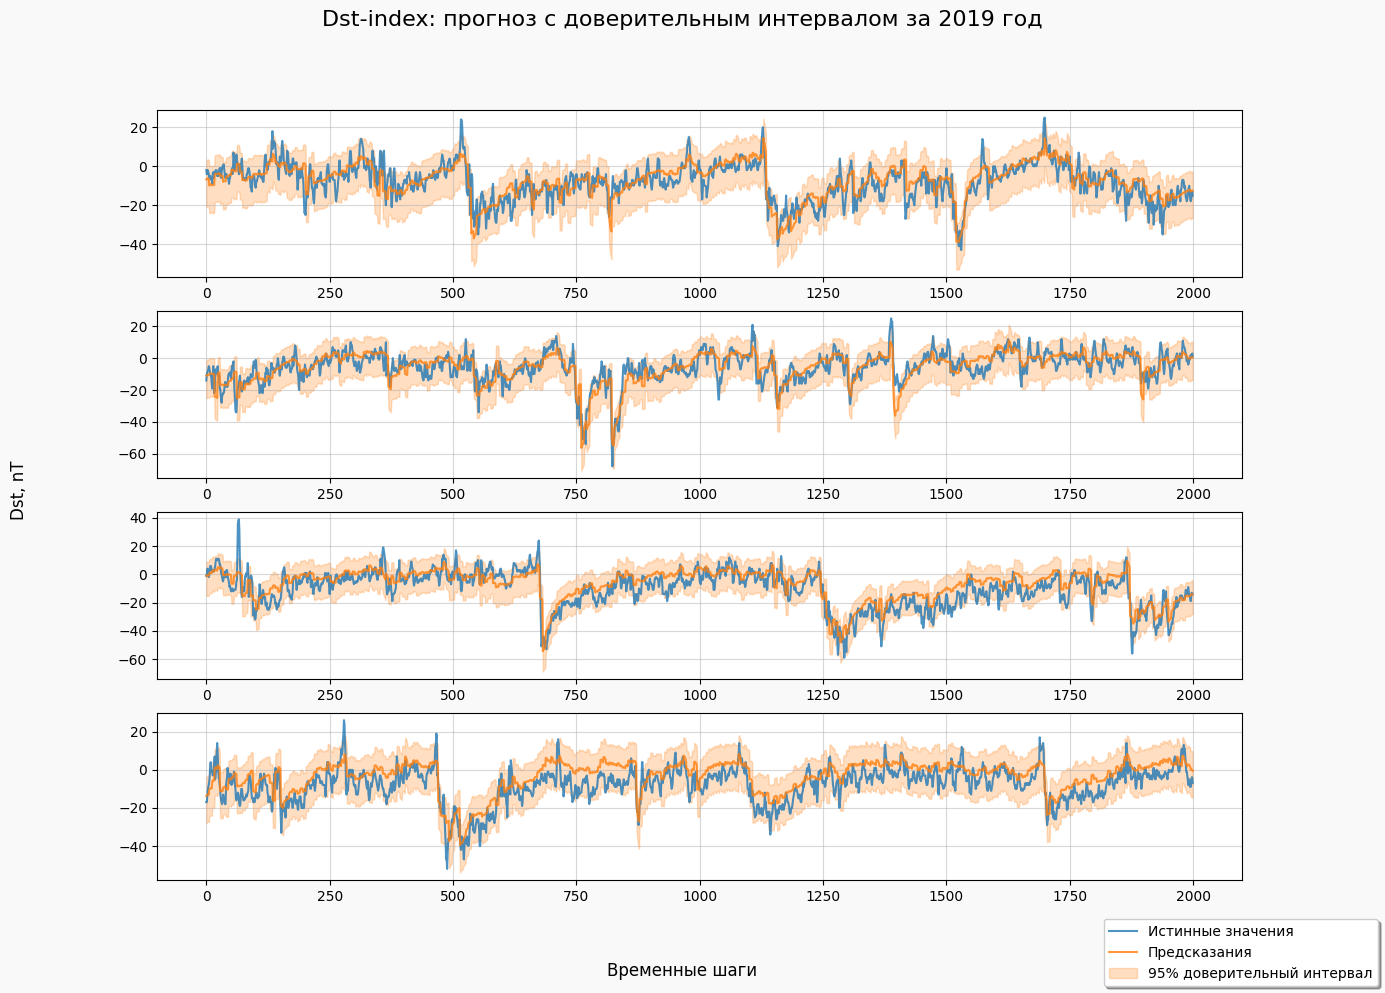

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes = axes.flatten()
fig
for idx, x in enumerate([(0, 2000), (2000, 4000), (4000, 6000,), (6000, 8000)]):
    start, end = x
    axes[idx].plot(dst_inference_2019["dst_labels"][start:end], label='Истинные значения', color='#1f77b4', linewidth=1.5, alpha=0.8)
    axes[idx].plot(dst_inference_2019["dst_preds"][start:end], label='Предсказания', color='#ff7f0e', linewidth=1.5, alpha=0.8)
    axes[idx].fill_between(
        range(len(dst_inference_2019["dst_preds"][start:end])), 
        dst_inference_2019["dst_ci_lower"][start:end], 
        dst_inference_2019["dst_ci_upper"][start:end], 
        color='#ff7f0e', 
        alpha=0.25, 
        label='95% доверительный интервал'
    )
    axes[idx].grid(alpha=0.5)

fig.suptitle('Dst-index: прогноз с доверительным интервалом за 2019 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('Dst, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.show()

In [92]:
limit = 8000
y_pred = dst_inference_2019["dst_preds"][:limit]
y_true = dst_inference_2019["dst_labels"][:limit]
calculate_forecasting_metrics(y_pred, y_true)

,Горизонт (часы),RMSE,MAE,MAPE (%)
0,1,6.53,5.10,1.871006e+08
1,3,6.05,4.78,3.966516e+15
2,6,5.46,4.36,2.051166e+15


In [87]:
dst_inference_2025 = inference_with_ci(dst_model, loader_by_2025, y_scaler, lmbda=lmbda)

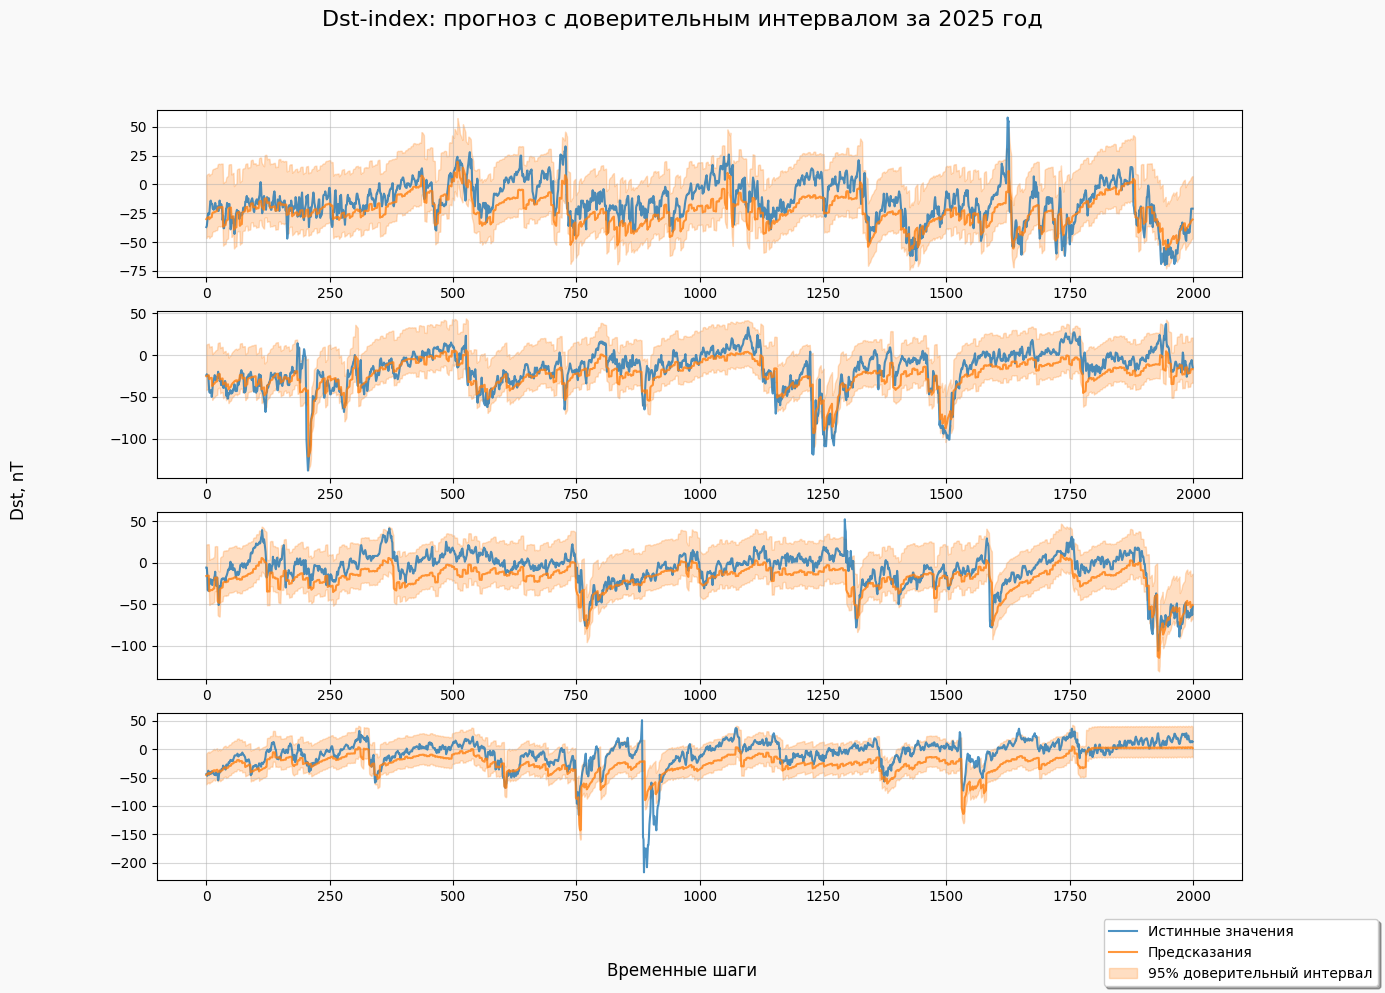

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes = axes.flatten()
fig
for idx, x in enumerate([(0, 2000), (2000, 4000), (4000, 6000,), (6000, 8000)]):
    start, end = x
    axes[idx].plot(dst_inference_2025["dst_labels"][start:end], label='Истинные значения', color='#1f77b4', linewidth=1.5, alpha=0.8)
    axes[idx].plot(dst_inference_2025["dst_preds"][start:end], label='Предсказания', color='#ff7f0e', linewidth=1.5, alpha=0.8)
    axes[idx].fill_between(
        range(len(dst_inference_2025["dst_preds"][start:end])), 
        dst_inference_2025["dst_ci_lower"][start:end], 
        dst_inference_2025["dst_ci_upper"][start:end], 
        color='#ff7f0e', 
        alpha=0.25, 
        label='95% доверительный интервал'
    )
    axes[idx].grid(alpha=0.5)

fig.suptitle('Dst-index: прогноз с доверительным интервалом за 2025 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('Dst, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.show()

In [88]:
limit = 8000
y_pred = dst_inference_2025["dst_preds"][:limit]
y_true = dst_inference_2025["dst_labels"][:limit]
calculate_forecasting_metrics(y_pred, y_true)

,Горизонт (часы),RMSE,MAE,MAPE (%)
0,1,17.47,13.78,4.897960e+08
1,3,16.90,13.43,1.774010e+16
2,6,16.25,13.10,8.068657e+15


### AE-index (индекс авроральной активности)

Отражает уровень магнитных возмущений в полярных областях, связанных с авроральными электроджетами

In [62]:
ae_inference_2019 = inference_with_ci(ae_model, loader_by_2019, y_scaler, lmbda=lmbda)

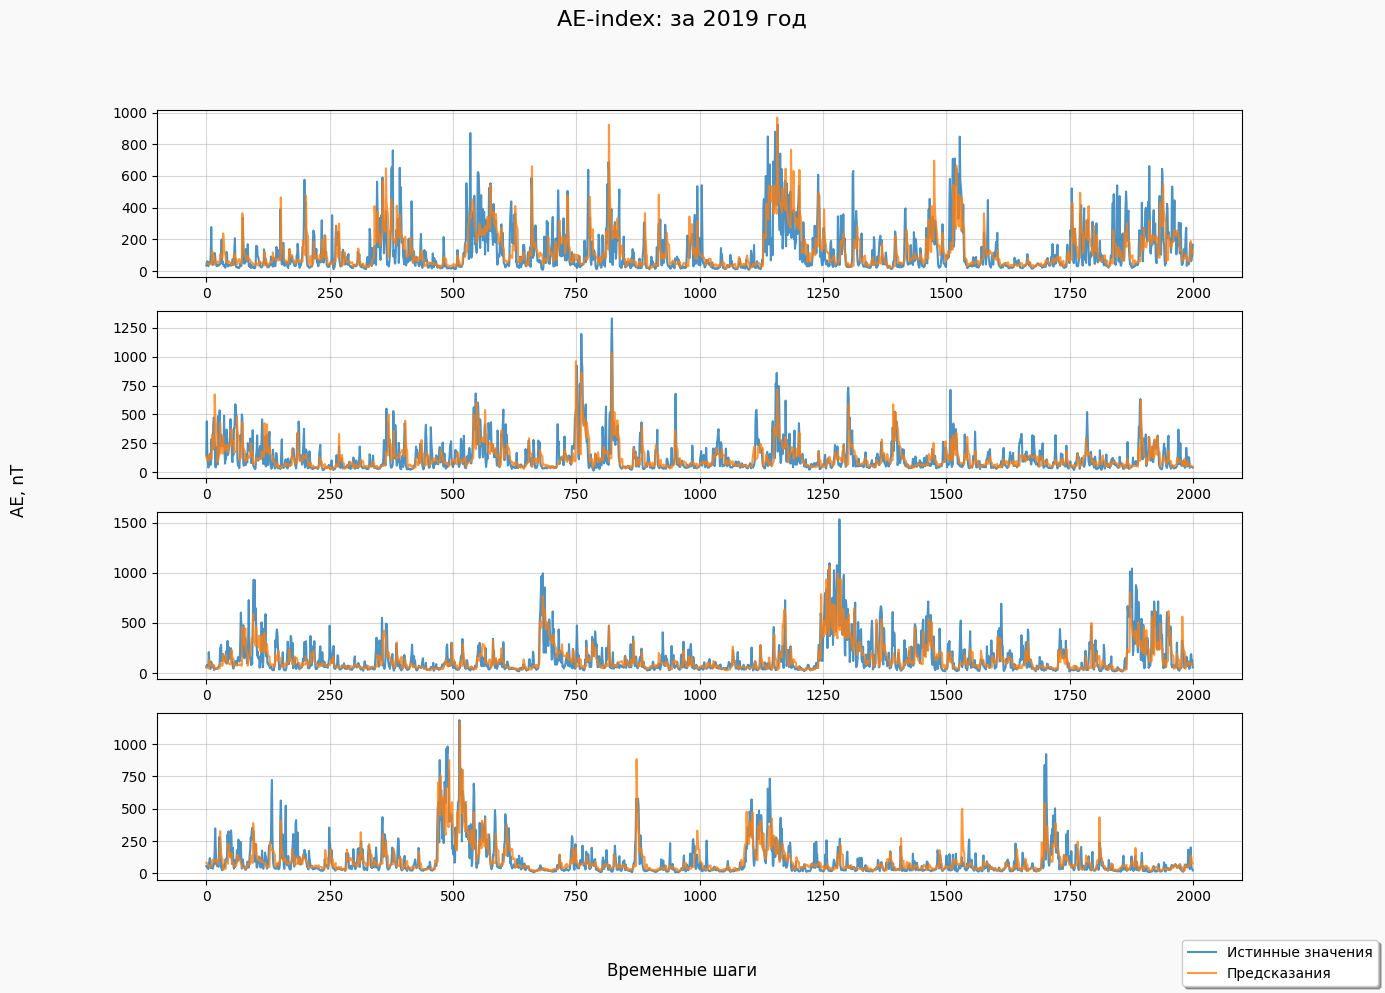

In [39]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes = axes.flatten()
fig
for idx, x in enumerate([(0, 2000), (2000, 4000), (4000, 6000,), (6000, 8000)]):
    start, end = x
    axes[idx].plot(ae_inference_2019["ae_labels"][start:end], label='Истинные значения', color='#1f77b4', linewidth=1.5, alpha=0.8)
    axes[idx].plot(ae_inference_2019["ae_preds"][start:end], label='Предсказания', color='#ff7f0e', linewidth=1.5, alpha=0.8)
    axes[idx].grid(alpha=0.5)

fig.suptitle('AE-index: за 2019 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('AE, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.show()

In [81]:
limit = 8000
y_pred = ae_inference_2019["ae_preds"][:limit]
y_true = ae_inference_2019["ae_labels"][:limit]
calculate_forecasting_metrics(y_pred, y_true)

,Горизонт (часы),RMSE,MAE,MAPE (%)
0,1,109.83,65.57,69.16
1,3,83.76,51.63,52.71
2,6,63.82,40.68,38.60


In [76]:
ae_inference_2025 = inference_with_ci(ae_model, loader_by_2025, y_scaler, lmbda=lmbda, n_points=7750)

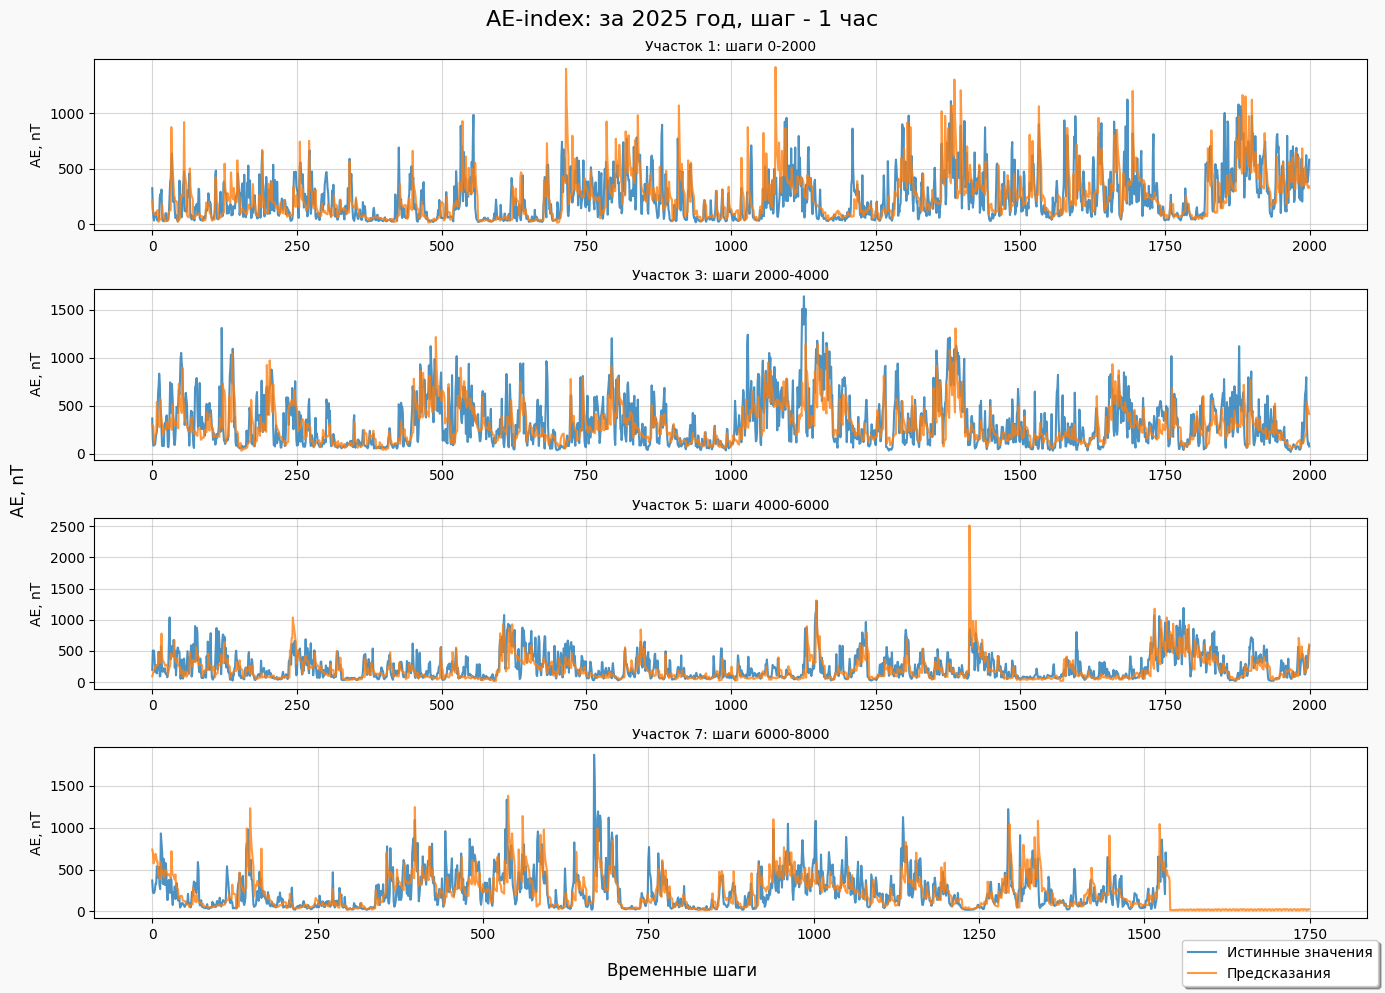

In [86]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes = axes.flatten()
fig
for idx, x in enumerate([(0, 2000), (2000, 4000), (4000, 6000,), (6000, 8000)]):
    start, end = x
    axes[idx].plot(ae_inference_2025["ae_labels"][start:end], label='Истинные значения', color='#1f77b4', linewidth=1.5, alpha=0.8)
    axes[idx].plot(ae_inference_2025["ae_preds"][start:end], label='Предсказания', color='#ff7f0e', linewidth=1.5, alpha=0.8)
    axes[idx].grid(alpha=0.5)
    axes[idx].set_ylabel('AE, nT', fontsize=10)
    axes[idx].set_title(f'Участок {start//1000+1}: шаги {start}-{end}', fontsize=10)

fig.suptitle('AE-index: за 2025 год, шаг - 1 час', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('AE, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [79]:
limit = 7500
y_pred = ae_inference_2025["ae_preds"][:limit]
y_true = ae_inference_2025["ae_labels"][:limit]
calculate_forecasting_metrics(y_pred, y_true)

,Горизонт (часы),RMSE,MAE,MAPE (%)
0,1,187.68,125.13,63.26
1,3,147.06,99.26,47.73
2,6,117.28,82.89,37.40


In [14]:
# for x, y in loader_by_2019:
    
#     break

# v2

In [26]:
def make_dataset_v2(
    path,
    x_scaler,
    y_scaler,
    X_window_size=24*7,
    y_window_size=6,
    batch_size=32,
    stride=6,
):
    dataset = pd.read_csv(path)
    dataset = dataset.drop(columns=["Unnamed: 0"])
    dataset['datetime'] = pd.to_datetime(
        dataset['Year'].astype(str) + '-' +
        dataset['Decimal Day'].astype(str) +
        ' ' +
        dataset['Hour'].astype(str),
        format='%Y-%j %H'
    )
    dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
    cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
    dataset = dataset[cols]

    fill_values = {
        "Bz_GSM": 999.9,
        "By_GSM": 999.9,
        "Bx_GSE": 999.9,
        "Kp": 99,
        "f10.7": 999.9,
        "AL": 99999,
        "AU": 99999,
        "T_proton": 9999999.,
        "Np_density": 999.9,
        "V_plasma": 9999.,
        "V_Long_GSE": 999.9,
        "V_Lat_GSE": 999.9,
        "Dst": 99999,
        "AE": 9999,
    }
    for col in dataset.drop(columns=["datetime"]).columns:
        dataset[col] = dataset[col].replace(fill_values[col], np.nan)

    clean_dataset = dataset.copy()
    features = [i for i in clean_dataset.columns if i != "datetime"]
    clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")

    dataset_to_preprocess = clean_dataset.copy()

    # lmbda = 0
    # ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

    # dataset_to_preprocess["AE"] = ae_log_data

    X_test, y_test = dataset_to_preprocess.drop(columns=["datetime"]), dataset_to_preprocess[["Dst", "AE"]]

    X_test_scaled = x_scaler.transform(X_test)

    y_test_scaled = y_scaler.transform(y_test)
    test_dataset = GeomagneticDataset(
        X=X_test_scaled,
        y=y_test_scaled,
        X_window_size=X_window_size,
        y_window_size=y_window_size,
        stride=stride,
    )
    val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return val_loader

In [24]:
def inference_with_ci_v2(model, loader, y_scaler, lmbda, device='cpu', alpha=0.95, n_points=8000):
    """Визуализация с доверительными интервалами - красивая версия для больших данных"""
    dst_labels = []
    ae_labels = []
    dst_preds = []
    ae_preds = []
    dst_errors = []
    ae_errors = []

    with torch.no_grad():
        model.eval()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            dst_pred, ae_pred, _ = model(x)
            
            preds = np.stack([dst_pred.cpu().numpy().flatten(), ae_pred.cpu().numpy().flatten()], axis=1)
            labels = np.stack([y[:, :, 0].cpu().numpy().flatten(), y[:, :, 1].cpu().numpy().flatten()], axis=1)
            
            preds = y_scaler.inverse_transform(preds)
            # preds[:, 1] = inv_boxcox(preds[:, 1], lmbda)
            labels = y_scaler.inverse_transform(labels)
            # labels[:, 1] = inv_boxcox(labels[:, 1], lmbda)
            
            dst_preds.extend(preds[:, 0])
            ae_preds.extend(preds[:, 1])
            dst_labels.extend(labels[:, 0])
            ae_labels.extend(labels[:, 1])
            dst_errors.extend(labels[:, 0] - preds[:, 0])
            ae_errors.extend(labels[:, 1] - preds[:, 1])
    
    dst_preds = np.array(dst_preds)
    ae_preds = np.array(ae_preds)
    dst_labels = np.array(dst_labels)
    ae_labels = np.array(ae_labels)
    dst_errors = np.array(dst_errors)
    ae_errors = np.array(ae_errors)
    
    dst_std = np.std(dst_errors)
    ae_std = np.std(ae_errors)
    dst_mean = np.mean(dst_errors)
    ae_mean = np.mean(ae_errors)
    
    z = stats.norm.ppf((1 + alpha) / 2)
    
    dst_ci_lower = dst_preds + (dst_mean - z * dst_std)
    dst_ci_upper = dst_preds + (dst_mean + z * dst_std)
    ae_ci_lower = ae_preds + (ae_mean - z * ae_std)
    ae_ci_upper = ae_preds + (ae_mean + z * ae_std)
    
    # Ограничиваем количество точек для показа (если данных больше n_points)
    n_total = len(dst_labels)
    if n_total > n_points:
        indices = np.linspace(0, n_total - 1, n_points, dtype=int)
        dst_labels = dst_labels[indices]
        dst_preds = dst_preds[indices]
        dst_ci_lower = dst_ci_lower[indices]
        dst_ci_upper = dst_ci_upper[indices]
        ae_labels = ae_labels[indices]
        ae_preds = ae_preds[indices]
        ae_ci_lower = ae_ci_lower[indices]
        ae_ci_upper = ae_ci_upper[indices]
    
    # Создаем красивый график
    # fig = plt.figure(figsize=(18, 8))
    
    # # DST
    # ax1 = plt.subplot(1, 2, 1)
    # ax1.plot(dst_labels, color='#1f77b4', linewidth=1.2, alpha=0.8, label='Истинные значения')
    # ax1.plot(dst_preds, color='#ff7f0e', linewidth=1.2, alpha=0.8, label='Предсказания')
    # ax1.fill_between(range(len(dst_preds)), dst_ci_lower, dst_ci_upper, 
    #                   color='#ff7f0e', alpha=0.25, label=f'Доверительный интервал ({int(alpha*100)}%)')
    # ax1.set_title('Индекс Dst', fontsize=14, fontweight='bold')
    # ax1.set_xlabel('Временные шаги', fontsize=12)
    # ax1.set_ylabel('Dst, nT', fontsize=12)
    # ax1.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    # ax1.grid(True, alpha=0.3, linestyle='--')
    # ax1.set_facecolor('#f9f9f9')
    
    # # Статистика для Dst
    # dst_rmse = np.sqrt(np.mean(dst_errors**2))
    # dst_mae = np.mean(np.abs(dst_errors))
    # ax1.text(0.02, 0.95, f'RMSE = {dst_rmse:.2f} nT\nMAE = {dst_mae:.2f} nT\nStd = {dst_std:.2f} nT', 
    #          transform=ax1.transAxes, fontsize=10, verticalalignment='top',
    #          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # # AE
    # ax2 = plt.subplot(1, 2, 2)
    # ax2.plot(ae_labels, color='#1f77b4', linewidth=1.2, alpha=0.8, label='Истинные значения')
    # ax2.plot(ae_preds, color='#ff7f0e', linewidth=1.2, alpha=0.8, label='Предсказания')
    # ax2.fill_between(range(len(ae_preds)), ae_ci_lower, ae_ci_upper, 
    #                   color='#ff7f0e', alpha=0.25, label=f'Доверительный интервал ({int(alpha*100)}%)')
    # ax2.set_title('Индекс AE', fontsize=14, fontweight='bold')
    # ax2.set_xlabel('Временные шаги', fontsize=12)
    # ax2.set_ylabel('AE, nT', fontsize=12)
    # ax2.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    # ax2.grid(True, alpha=0.3, linestyle='--')
    # ax2.set_facecolor('#f9f9f9')
    
    # # Статистика для AE
    # ae_rmse = np.sqrt(np.mean(ae_errors**2))
    # ae_mae = np.mean(np.abs(ae_errors))
    # ax2.text(0.02, 0.95, f'RMSE = {ae_rmse:.2f} nT\nMAE = {ae_mae:.2f} nT\nStd = {ae_std:.2f} nT', 
    #          transform=ax2.transAxes, fontsize=10, verticalalignment='top',
    #          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # plt.suptitle('Прогнозирование геомагнитных индексов с доверительными интервалами', 
    #              fontsize=16, fontweight='bold', y=1.02)
    # plt.tight_layout()
    # plt.show()
    
    return {
        "dst_ci_lower": dst_ci_lower,
        "dst_ci_upper": dst_ci_upper,
        "ae_ci_lower": ae_ci_lower,
        "ae_ci_upper": ae_ci_upper,
        "dst_labels": dst_labels,
        "dst_preds": dst_preds,
        "ae_labels": ae_labels,
        "ae_preds": ae_preds,
        "dst_rmse": np.sqrt(np.mean(dst_errors**2)),
        "ae_rmse": np.sqrt(np.mean(ae_errors**2)),
        "dst_std": dst_std,
        "ae_std": ae_std,
    }

In [48]:
X_scaler = joblib.load("../data/weights/v2/X_scaler.joblib")
y_scaler = joblib.load("../data/weights/v2/y_scaler.joblib")
forecasts_len = 6

net_v2 = GeomagneticNetV11(
    lstm_input_size=14,
    lstm_hidden_size=256,
    lstm_num_layers=4,
    lstm_dropout=0.2,
    dst_attention_heads=2,
    ae_attention_heads=2,
    forecasts_len=forecasts_len,
)
net_v2.load_state_dict(torch.load("../data/weights/v2/best.pt", map_location="cpu"))

<All keys matched successfully>

In [49]:
loader_by_2019_v2 = make_dataset_v2(
    path="../data/datasets/test_2019.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
)
loader_by_2025_v2 = make_dataset_v2(
    path="../data/datasets/test_2025.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
)

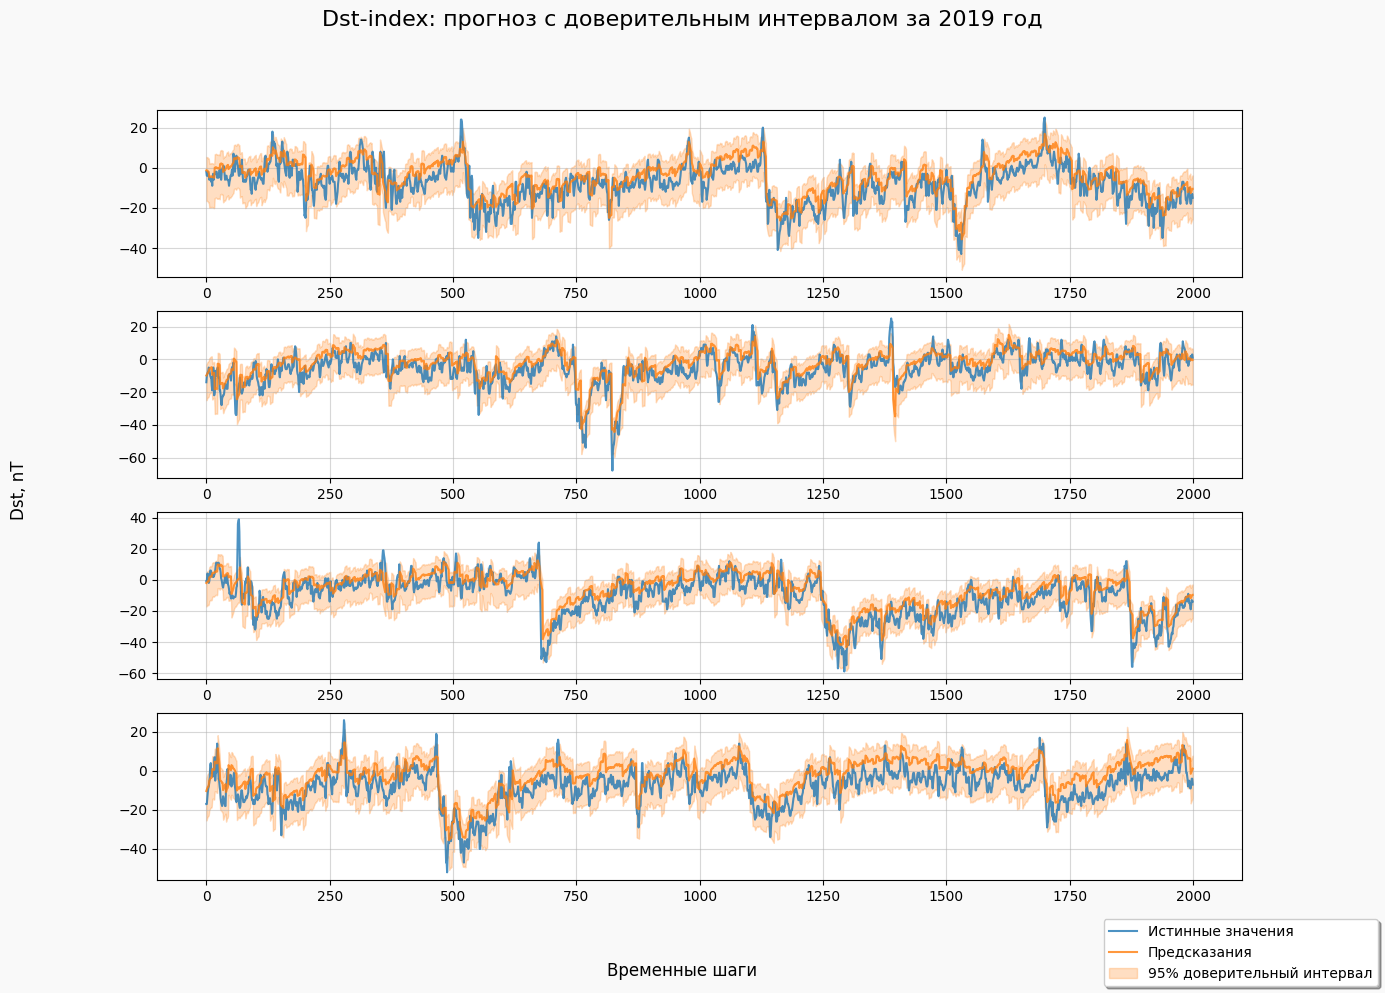

In [50]:
dst_inference_2019 = inference_with_ci_v2(net_v2, loader_by_2019_v2, y_scaler, lmbda=lmbda)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes = axes.flatten()
fig
for idx, x in enumerate([(0, 2000), (2000, 4000), (4000, 6000,), (6000, 8000)]):
    start, end = x
    axes[idx].plot(dst_inference_2019["dst_labels"][start:end], label='Истинные значения', color='#1f77b4', linewidth=1.5, alpha=0.8)
    axes[idx].plot(dst_inference_2019["dst_preds"][start:end], label='Предсказания', color='#ff7f0e', linewidth=1.5, alpha=0.8)
    axes[idx].fill_between(
        range(len(dst_inference_2019["dst_preds"][start:end])), 
        dst_inference_2019["dst_ci_lower"][start:end], 
        dst_inference_2019["dst_ci_upper"][start:end], 
        color='#ff7f0e', 
        alpha=0.25, 
        label='95% доверительный интервал'
    )
    axes[idx].grid(alpha=0.5)

fig.suptitle('Dst-index: прогноз с доверительным интервалом за 2019 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('Dst, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.show()

In [52]:
limit = 8000
y_pred = dst_inference_2019["dst_preds"][:limit]
y_true = dst_inference_2019["dst_labels"][:limit]
calculate_forecasting_metrics(y_pred, y_true)

,Горизонт (часы),RMSE,MAE,MAPE (%)
0,1,6.98,5.54,2.315536e+08
1,3,6.49,5.25,5.770918e+15
2,6,5.92,4.89,3.972959e+15


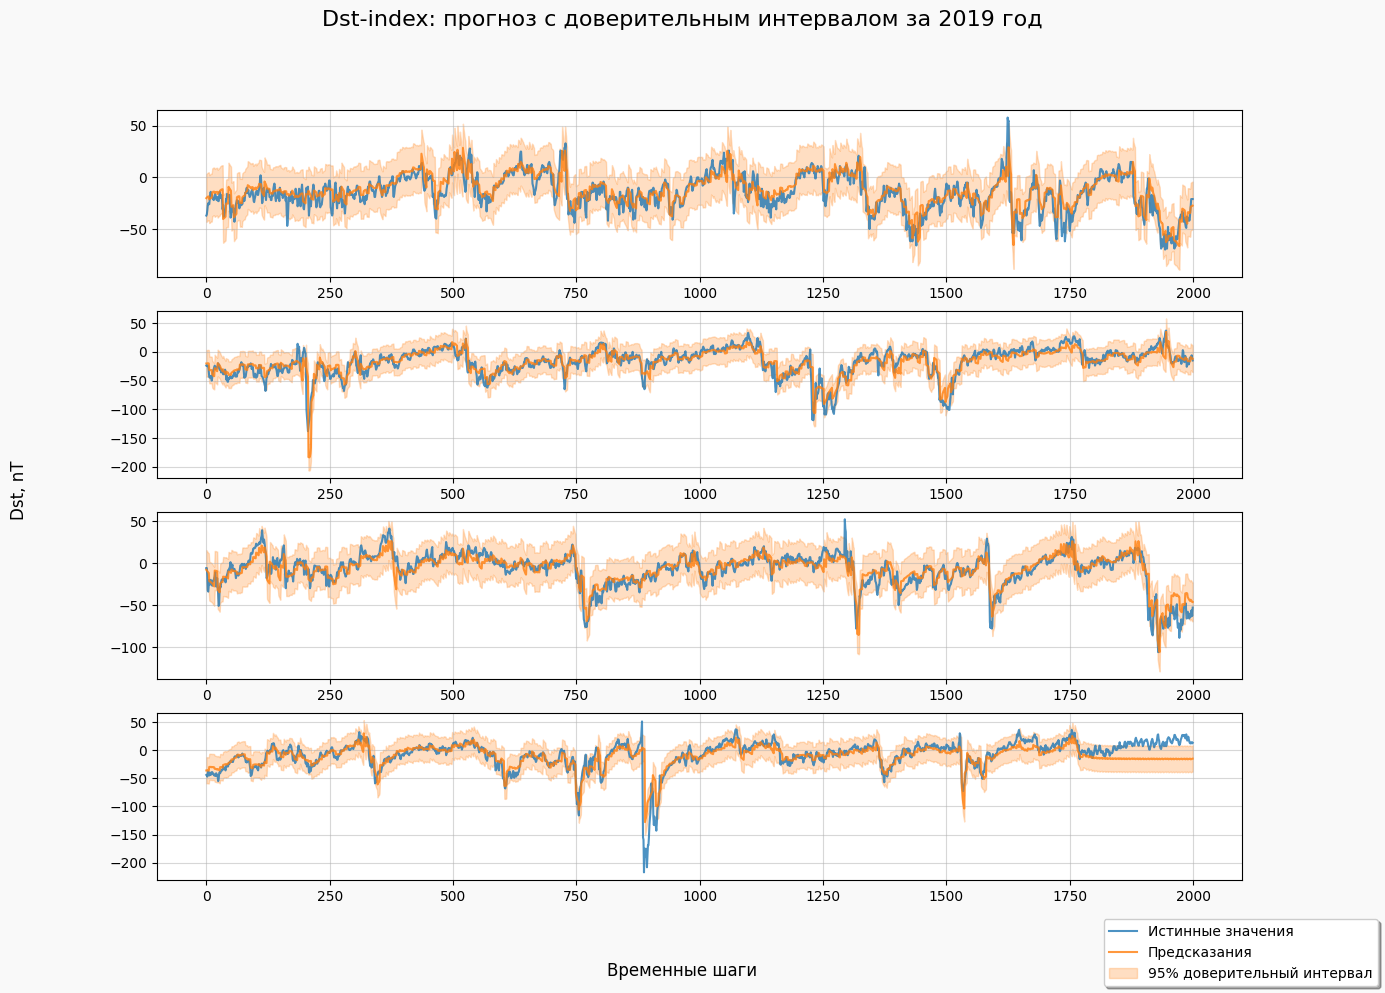

In [53]:
dst_inference_2025 = inference_with_ci_v2(net_v2, loader_by_2025_v2, y_scaler, lmbda=lmbda)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes = axes.flatten()
fig
for idx, x in enumerate([(0, 2000), (2000, 4000), (4000, 6000,), (6000, 8000)]):
    start, end = x
    axes[idx].plot(dst_inference_2025["dst_labels"][start:end], label='Истинные значения', color='#1f77b4', linewidth=1.5, alpha=0.8)
    axes[idx].plot(dst_inference_2025["dst_preds"][start:end], label='Предсказания', color='#ff7f0e', linewidth=1.5, alpha=0.8)
    axes[idx].fill_between(
        range(len(dst_inference_2025["dst_preds"][start:end])), 
        dst_inference_2025["dst_ci_lower"][start:end], 
        dst_inference_2025["dst_ci_upper"][start:end], 
        color='#ff7f0e', 
        alpha=0.25, 
        label='95% доверительный интервал'
    )
    axes[idx].grid(alpha=0.5)

fig.suptitle('Dst-index: прогноз с доверительным интервалом за 2019 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('Dst, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.show()

In [54]:
limit = 8000
y_pred = dst_inference_2025["dst_preds"][:limit]
y_true = dst_inference_2025["dst_labels"][:limit]
calculate_forecasting_metrics(y_pred, y_true)

,Горизонт (часы),RMSE,MAE,MAPE (%)
0,1,11.87,7.66,1.740593e+08
1,3,10.80,6.95,3.692243e+15
2,6,9.61,6.22,1.411074e+15
